In [1]:
import torch
import torch.nn as nn
from torch.utils.data import ConcatDataset, Subset, DataLoader
import numpy as np

from dataset import create_dataloaders
from gan_model import MEGGAN
from train import train_one_epoch
from evaluate import evaluate, evaluate_top_models_person_cv
from grid_search import run_grid_search, run_person_grid_search

In [2]:
params = {
    "learning_rate": 5e-3,
    "hidden_channels": 32,
    "kernel_size": 3,
    "dropout": 0.1,
    "num_heads": 2,
    "weight_decay": 1e-4,
    "batch_size": 8,
}

BATCH_SIZE = 8

INTRA_DATA_DIR = "preprocessed_data/Intra"
intra_train_loader, intra_test_loader = create_dataloaders(INTRA_DATA_DIR, BATCH_SIZE, add_person_id=True)

CROSS_DATA_DIR = "preprocessed_data/Cross"
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

cross_train_loader, cross_test_loader = create_dataloaders(CROSS_DATA_DIR, BATCH_SIZE, add_person_id=True)

Loading test data...
Loading train data...
Loaded 32 training samples
Loaded 8 test samples
Class distribution in training: [8 8 8 8]
Class distribution in test: [2 2 2 2]
Train batches: 4
Test batches: 1
Using device: cuda
Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]
Train batches: 8
Test batches: 6


In [3]:
cross_dataset = cross_train_loader.dataset
intra_dataset = intra_train_loader.dataset

def build_person_subsets(dataset, source_name):
    """Build subsets of the dataset grouped by person_id."""
    if dataset.person_ids is None:
        raise ValueError(f"{source_name} dataset must be created with add_person_id=True")

    grouped_indices = {}
    for index, person_id in enumerate(dataset.person_ids):
        grouped_indices.setdefault(int(person_id), []).append(index)

    return [
        (f"{source_name}_{person_id}", Subset(dataset, indices), person_id)
        for person_id, indices in sorted(grouped_indices.items())
    ]


cross_person_splits = build_person_subsets(cross_dataset, "cross")
intra_person_splits = build_person_subsets(intra_dataset, "intra")
person_splits = cross_person_splits + intra_person_splits

print("Person-level folds:")
for split_name, subset, person_id in person_splits:
    print(f"  {split_name}: person_id={person_id}, samples={len(subset)}")

Person-level folds:
  cross_113922: person_id=113922, samples=32
  cross_164636: person_id=164636, samples=32
  intra_105923: person_id=105923, samples=32


In [16]:
train_dataset = ConcatDataset([subset for _, subset, _ in cross_person_splits])
train_loader = DataLoader(
    train_dataset,
    batch_size=params["batch_size"],
    shuffle=True,
)
validation_dataset = ConcatDataset([subset for _, subset, _ in intra_person_splits])
validation_loader = DataLoader(
    validation_dataset,
    batch_size=params["batch_size"],
    shuffle=False,
)

model_kwargs = {
    "hidden_channels": params["hidden_channels"],
    "kernel_size": params["kernel_size"],
    "dropout": params["dropout"],
    "num_heads": params["num_heads"],
    "num_classes": NUM_CLASSES,
}

PATIENCE = 16

average_results = []
best_run_index = -1
best_run_score = float("-inf")
best_model_state = None
best_model_result = None

for run in range(10):
    model = MEGGAN(**model_kwargs).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=max(1, PATIENCE // 2),
        factor=0.5,
    )

    num_epochs = params.get("epochs", 100)
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state_dict = None
    bad_epochs = 0

    min_delta = 1e-4


    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        scheduler.step(train_loss)

        val_loss, val_acc = evaluate(model, validation_loader, criterion, DEVICE)
        scheduler.step(val_loss)

        # Keep the checkpoint with the lowest validation loss.
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        # Evaluate on cross test set
        #test_loss, test_acc = evaluate(model, cross_test_loader, criterion, DEVICE)
        #print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        print(f"Epoch {epoch + 1}/{num_epochs} | Train Acc: {train_acc:.2f} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f} | Val Loss: {val_loss:.4f}")

        # Stop once validation loss has not improved for several epochs.
        if bad_epochs >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch + 1} after {PATIENCE} "
                "non-improving epochs."
            )
            break
        

    test_result = evaluate(model, cross_test_loader, criterion, DEVICE)
    print(f"Cross test result: {test_result}")
    average_results.append(test_result)

    if test_result[1] > best_run_score:
        best_run_score = test_result[1]
        best_run_index = run
        best_model_result = test_result
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

average_loss = np.mean([result[0] for result in average_results])
average_acc = np.mean([result[1] for result in average_results])
stdev_loss = np.std([result[0] for result in average_results])
stdev_acc = np.std([result[1] for result in average_results])

print(f"Average Loss: {average_loss:.4f} ± {stdev_loss:.4f}")
print(f"Average Accuracy: {average_acc:.2f}% ± {stdev_acc:.2f}%")

best_model = MEGGAN(**model_kwargs).to(DEVICE)
if best_model_state is not None:
    best_model.load_state_dict(best_model_state)
    best_model.eval()
    print(f"Best run: {best_run_index + 1} | Best test result: {best_model_result}")

Epoch 1/100 | Train Acc: 54.6875 | Train Loss: 1.0849 | Val Acc: 62.5000 | Val Loss: 0.7808
Epoch 2/100 | Train Acc: 95.3125 | Train Loss: 0.5449 | Val Acc: 62.5000 | Val Loss: 0.7698
Epoch 3/100 | Train Acc: 81.2500 | Train Loss: 0.5272 | Val Acc: 65.6250 | Val Loss: 0.7873
Epoch 4/100 | Train Acc: 85.9375 | Train Loss: 0.3862 | Val Acc: 65.6250 | Val Loss: 0.7658
Epoch 5/100 | Train Acc: 93.7500 | Train Loss: 0.2459 | Val Acc: 68.7500 | Val Loss: 0.7124
Epoch 6/100 | Train Acc: 93.7500 | Train Loss: 0.2196 | Val Acc: 71.8750 | Val Loss: 0.5607
Epoch 7/100 | Train Acc: 93.7500 | Train Loss: 0.2125 | Val Acc: 84.3750 | Val Loss: 0.4034
Epoch 8/100 | Train Acc: 100.0000 | Train Loss: 0.0932 | Val Acc: 84.3750 | Val Loss: 0.4591
Epoch 9/100 | Train Acc: 100.0000 | Train Loss: 0.0629 | Val Acc: 96.8750 | Val Loss: 0.1912
Epoch 10/100 | Train Acc: 100.0000 | Train Loss: 0.0626 | Val Acc: 100.0000 | Val Loss: 0.1379
Epoch 11/100 | Train Acc: 93.7500 | Train Loss: 0.1398 | Val Acc: 96.8750 |

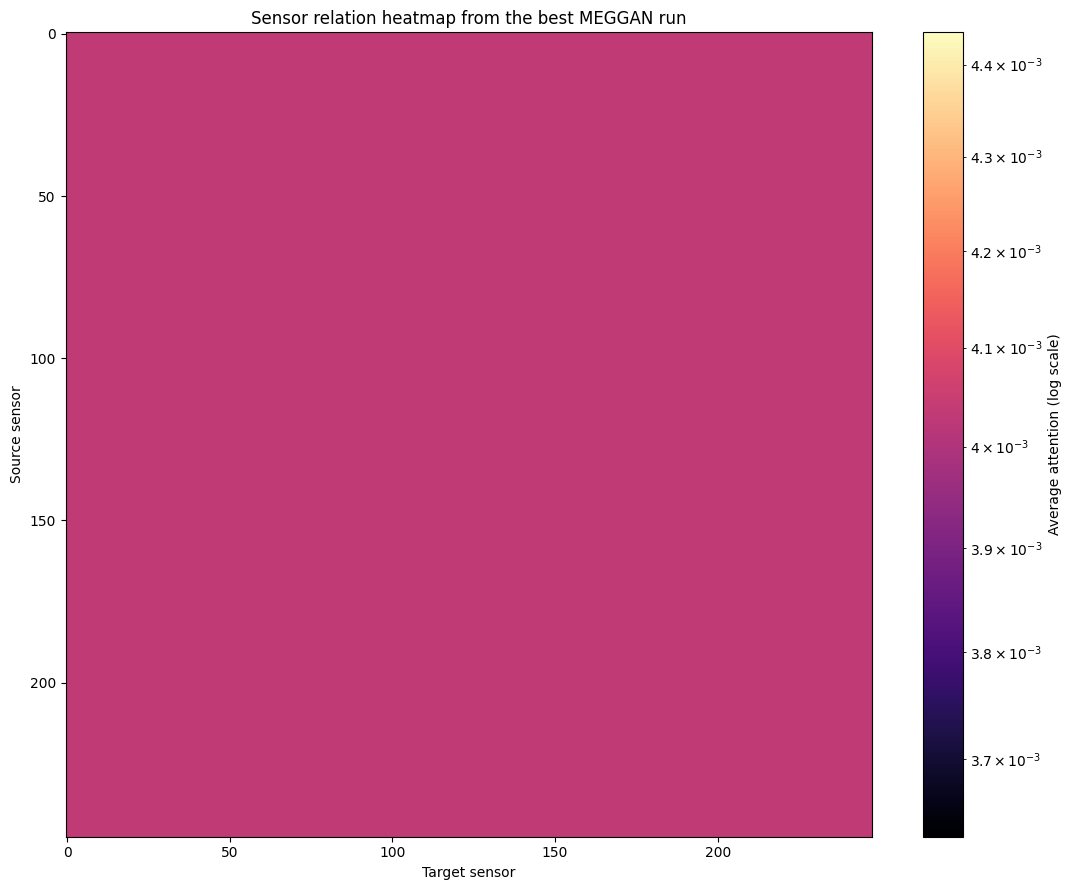

Top sensor relations:
  sensor 238 -> sensor 245: 0.0040
  sensor 238 -> sensor 244: 0.0040
  sensor 238 -> sensor 243: 0.0040
  sensor 238 -> sensor 242: 0.0040
  sensor 238 -> sensor 241: 0.0040
  sensor 238 -> sensor 240: 0.0040
  sensor 238 -> sensor 239: 0.0040
  sensor 237 -> sensor 247: 0.0040
  sensor 237 -> sensor 246: 0.0040
  sensor 237 -> sensor 245: 0.0040
  sensor 237 -> sensor 244: 0.0040
  sensor 237 -> sensor 243: 0.0040
  sensor 237 -> sensor 242: 0.0040
  sensor 237 -> sensor 241: 0.0040
  sensor 241 -> sensor 242: 0.0040
  sensor 240 -> sensor 247: 0.0040
  sensor 240 -> sensor 246: 0.0040
  sensor 240 -> sensor 245: 0.0040
  sensor 240 -> sensor 244: 0.0040
  sensor 240 -> sensor 243: 0.0040
  sensor 240 -> sensor 242: 0.0040
  sensor 240 -> sensor 241: 0.0040
  sensor 239 -> sensor 247: 0.0040
  sensor 239 -> sensor 246: 0.0040
  sensor 239 -> sensor 245: 0.0040
  sensor 239 -> sensor 244: 0.0040
  sensor 239 -> sensor 243: 0.0040
  sensor 239 -> sensor 242: 0.004

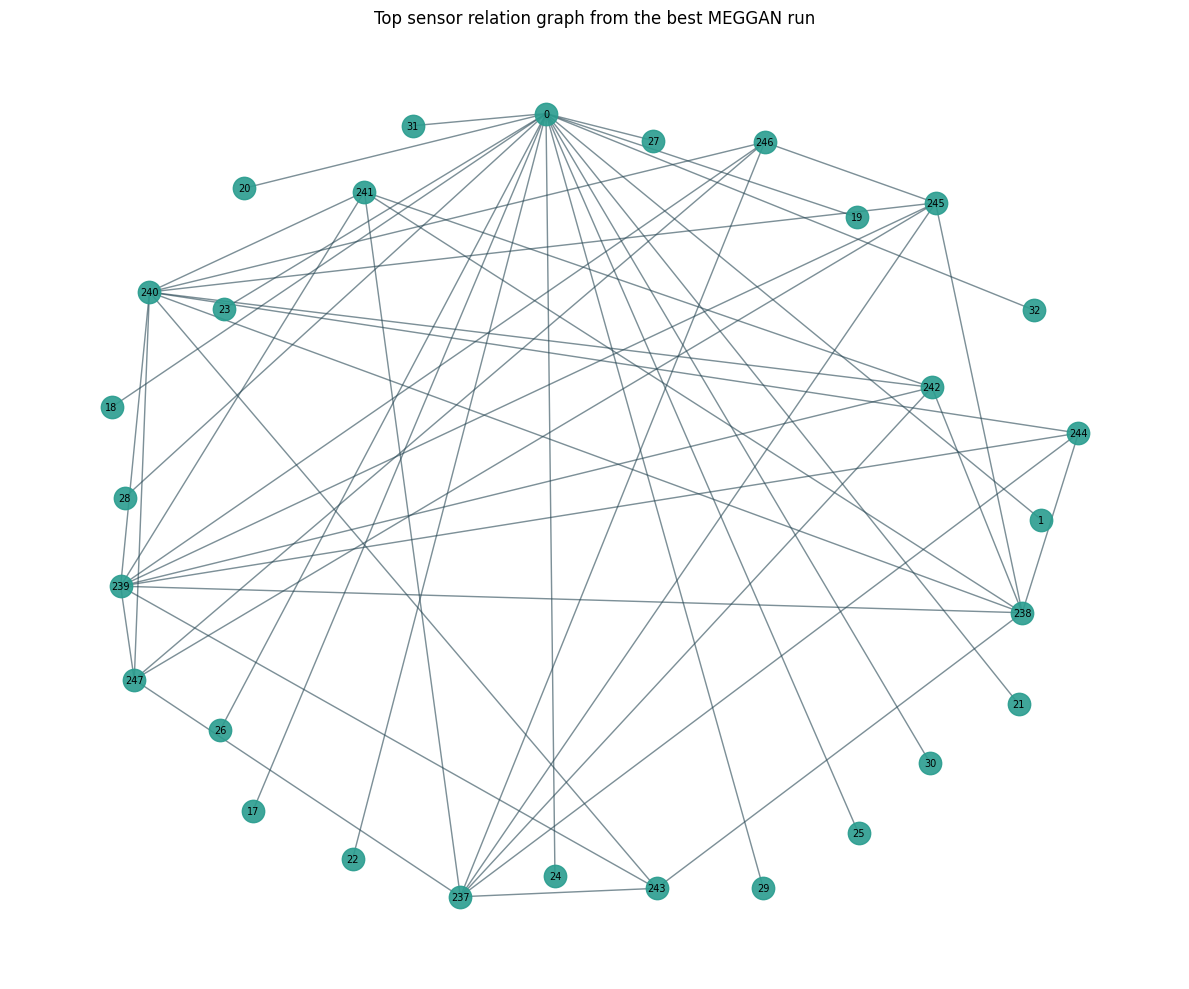

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

try:
    import networkx as nx
except ImportError:
    nx = None


@torch.no_grad()
def extract_attention_matrix(source_model, loader, device, max_batches=None):
    source_model.eval()
    attention_block = source_model.sensor_attention

    aggregated_attention = None
    sample_count = 0

    for batch_index, batch in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        if len(batch) == 2:
            x, _ = batch
        else:
            x, _, _ = batch

        x = x.to(device)
        node_features = source_model.sensor_encoder(x)
        batch_size, num_nodes, _ = node_features.shape

        query = attention_block.query(node_features).reshape(
            batch_size,
            num_nodes,
            attention_block.num_heads,
            attention_block.head_dim,
        )
        key = attention_block.key(node_features).reshape(
            batch_size,
            num_nodes,
            attention_block.num_heads,
            attention_block.head_dim,
        )

        query = query.permute(0, 2, 1, 3)
        key = key.permute(0, 2, 1, 3)

        attention_logits = torch.matmul(query, key.transpose(-1, -2))
        attention_logits = attention_logits / (attention_block.head_dim ** 0.5)
        attention = torch.softmax(attention_logits, dim=-1)

        mean_attention = attention.mean(dim=1)

        if aggregated_attention is None:
            aggregated_attention = mean_attention.sum(dim=0)
        else:
            aggregated_attention += mean_attention.sum(dim=0)

        sample_count += batch_size

    return (aggregated_attention / sample_count).cpu().numpy()


def plot_sensor_relations(attention_matrix, top_k=40):
    heatmap = np.clip(attention_matrix, np.finfo(float).tiny, None)
    plt.figure(figsize=(11, 9))
    plt.imshow(heatmap, cmap="magma", aspect="auto", norm=LogNorm(vmin=heatmap.min(), vmax=heatmap.max()))
    plt.colorbar(label="Average attention (log scale)")
    plt.title("Sensor relation heatmap from the best MEGGAN run")
    plt.xlabel("Target sensor")
    plt.ylabel("Source sensor")
    plt.tight_layout()
    plt.show()

    num_sensors = attention_matrix.shape[0]
    upper_row_idx, upper_col_idx = np.triu_indices(num_sensors, k=1)
    edge_weights = attention_matrix[upper_row_idx, upper_col_idx]

    if top_k > len(edge_weights):
        top_k = len(edge_weights)

    top_positions = np.argpartition(edge_weights, -top_k)[-top_k:]
    top_edges = sorted(
        [
            (int(upper_row_idx[position]), int(upper_col_idx[position]), float(edge_weights[position]))
            for position in top_positions
        ],
        key=lambda item: item[2],
        reverse=True,
    )

    print("Top sensor relations:")
    for source_sensor, target_sensor, weight in top_edges:
        print(f"  sensor {source_sensor} -> sensor {target_sensor}: {weight:.4f}")

    if nx is None:
        return

    graph = nx.Graph()
    graph.add_nodes_from(range(num_sensors))
    graph.add_weighted_edges_from(top_edges)

    if graph.number_of_edges() == 0:
        return

    focus_nodes = sorted({node for edge in top_edges for node in edge[:2]})
    subgraph = graph.subgraph(focus_nodes).copy()

    plt.figure(figsize=(12, 10))
    positions = nx.spring_layout(subgraph, seed=42, k=0.8)
    edge_widths = [1.0 + 6.0 * subgraph[u][v]["weight"] for u, v in subgraph.edges()]
    nx.draw_networkx_nodes(subgraph, positions, node_size=260, node_color="#2a9d8f", alpha=0.9)
    nx.draw_networkx_edges(subgraph, positions, width=edge_widths, alpha=0.6, edge_color="#264653")
    nx.draw_networkx_labels(subgraph, positions, font_size=7, font_color="black")
    plt.title("Top sensor relation graph from the best MEGGAN run")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


reference_model = globals().get("best_model", model)
attention_matrix = extract_attention_matrix(reference_model, cross_test_loader, DEVICE, max_batches=4)
plot_sensor_relations(attention_matrix, top_k=50)